In [92]:
import os,sys
import time,datetime
import yaml,json

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tbparse

In [93]:
SCRIPT_DIR = os.getcwd()
WORKING_DIR = f'{SCRIPT_DIR}/_temp_old1'
PARENT_LOG_DIR = f'{SCRIPT_DIR}/_temp_old1/lightning_logs/cpu_2024-12-07'
LOG_DIRS = os.listdir(PARENT_LOG_DIR)
print(LOG_DIRS)

['TraverseAvgPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest', 'TraverseNN-FourLeafTrain-ON-FourLeafTest', 'TraverseMaxPooling-FourLeafTrain-ON-FourLeafTest', 'TraverseAvgPooling-FourLeafTrain-ON-FourLeafTest', 'TraverseMaxPooling-FourLeafFourSiteTrain', 'TraverseAvgPooling-FourLeafFourSiteTrain', 'TraverseNN-FourLeafFourSiteTrain', 'TraverseAvgPooling-FourLeafTrain', 'TraverseNN-FourLeafTrain', 'TraverseMaxPooling-FourLeafTrain', 'TraverseNN-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest', 'TraverseMaxPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest']


In [94]:
# load config settings
with open(f'{SCRIPT_DIR}/config.yaml', 'r') as fp:
    config_settings = yaml.safe_load(fp)
config_settings

{'models': ['TraverseNN', 'TraverseMaxPooling', 'TraverseAvgPooling'],
 'train_data': ['FourLeafTrain', 'FourLeafFourSiteTrain'],
 'test_data': ['FourLeafTest', 'FourLeafFourSiteTest'],
 'device': 'cpu'}

In [145]:
def get_model_dir(model_name, train_data_name, test_data_name=None):
    path = f'{model_name}-{train_data_name}'
    if test_data_name:
        path = f'{path}-ON-{test_data_name}'
    return path

def get_lightning_log_path(model_name, train_data_name, device, timestamp, root_dir=SCRIPT_DIR, test_data_name=None):
    path = f'{root_dir}/lightning_logs/{device}_{timestamp}/{get_model_dir(model_name, train_data_name, test_data_name)}'
    return path

def get_hyperparam_log_path(model_name, train_data_name, device, timestamp, root_dir=SCRIPT_DIR, test_data_name=None):
    path = f'{root_dir}/hyper_checkpoints/{get_model_dir(model_name, train_data_name, test_data_name)}'
    return path

def get_df_from_tblog(log_path):
    reader = tbparse.SummaryReader(log_path)
    return reader.scalars

In [139]:
def plot_from_summary_df(df, tag='loss', ylabel='Loss', title='Training Loss', legend_name=None):
    loss_data = df[df['tag'] == tag]
    plt.plot(loss_data['step'], loss_data['value'], label=legend_name)
    plt.xlabel('step')
    plt.ylabel(ylabel)
    plt.title(title)

def plot_all_from_summary_df_dict(df_dict, tags=None, ignore_tags=[]):
    if not tags:
        tags = set(df_dict[next(iter(df_dict))].tag)
    for tag in tags:
        if tag in ignore_tags:
            continue
        for key,df in df_dict.items():
            plot_from_summary_df(df, tag=tag, ylabel=f'{tag}', title=f'{tag}', legend_name=key)
        plt.legend()
        plt.show()

In [ ]:
model_name = 'TraverseNN'
train_data_name = 'FourLeafTrain'
test_data_name = 'FourLeafTest'

root_dir=f'{SCRIPT_DIR}/_temp_old1'
timestamp='2024-12-05'
device='cpu'

h_path = get_hyperparam_log_path(model_name, train_data_name, device, timestamp, root_dir=root_dir, test_data_name=None)
l_path = get_lightning_log_path(model_name, train_data_name, device, timestamp, root_dir=root_dir, test_data_name=None)
ltest_path = get_lightning_log_path(model_name, train_data_name, device, timestamp, root_dir=root_dir, test_data_name=test_data_name)

h_df = get_df_from_tblog(h_path)
print('h_df:', set(h_df.tag))
l_df = get_df_from_tblog(l_path)
print('l_df:', set(l_df.tag))
ltest_df = get_df_from_tblog(ltest_path)
print('ltest_df:', set(ltest_df.tag))

# for tag in set(h_df.tag):
#     if tag == 'epoch':
#         continue
#     print('h_tag:', tag)
#     plot_from_summary_df(h_df, tag, ylabel=tag, title=tag)
#     plt.show()
# for tag in set(l_df.tag):
#     if tag == 'epoch':
#         continue
#     print('l_tag:', tag)
#     plot_from_summary_df(l_df, tag, ylabel=tag, title=tag)
#     plt.show()


h_df: {'train_wall_time', 'val_loss', 'neg_prediction_avg', 'pos_prediction_avg', 'epoch', 'val_wall_time', 'train_loss_epoch', 'train_loss_step', 'loss'}
l_df: {'val_loss', 'neg_prediction_avg', 'pos_prediction_avg', 'epoch', 'train_loss_epoch', 'train_loss_step', 'loss'}
l_df: {'epoch', 'test_loss', 'test_auroc'}


In [114]:
summary_dfs = {}
for log_dir in LOG_DIRS:
    reader = tbparse.SummaryReader(f'{PARENT_LOG_DIR}/{log_dir}/version_0')
    df = reader.scalars
    summary_dfs[log_dir] = reader.scalars
    # sub_dirs = os.listdir(f'{PARENT_LOG_DIR}/{log_dir}')
    print(f'log_dir: {log_dir}')
    # print(f'sub_dirs: {sub_dirs}')

log_dir: TraverseAvgPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest
log_dir: TraverseNN-FourLeafTrain-ON-FourLeafTest
log_dir: TraverseMaxPooling-FourLeafTrain-ON-FourLeafTest
log_dir: TraverseAvgPooling-FourLeafTrain-ON-FourLeafTest
log_dir: TraverseMaxPooling-FourLeafFourSiteTrain
log_dir: TraverseAvgPooling-FourLeafFourSiteTrain
log_dir: TraverseNN-FourLeafFourSiteTrain
log_dir: TraverseAvgPooling-FourLeafTrain
log_dir: TraverseNN-FourLeafTrain
log_dir: TraverseMaxPooling-FourLeafTrain
log_dir: TraverseNN-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest
log_dir: TraverseMaxPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest


In [122]:
model_names = set()
train_data_names = set()
test_data_names = set()

for key,df in summary_dfs.items():
    print(f'key: {key}')
    print(f'len: {len(df)}')

    fields = key.split("-")
    model_names.add(fields[0])
    train_data_names.add(fields[1])
    if len(fields) == 4:
      test_data_names.add(fields[3])

model_names = list(model_names)
train_data_names = list(train_data_names)
test_data_names = list(test_data_names)

print(f'model_names: {model_names}')
print(f'train_data_names: {train_data_names}')
print(f'test_data_names: {test_data_names}')

key: TraverseAvgPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest
len: 4
key: TraverseNN-FourLeafTrain-ON-FourLeafTest
len: 4
key: TraverseMaxPooling-FourLeafTrain-ON-FourLeafTest
len: 4
key: TraverseAvgPooling-FourLeafTrain-ON-FourLeafTest
len: 4
key: TraverseMaxPooling-FourLeafFourSiteTrain
len: 573
key: TraverseAvgPooling-FourLeafFourSiteTrain
len: 1202
key: TraverseNN-FourLeafFourSiteTrain
len: 11518
key: TraverseAvgPooling-FourLeafTrain
len: 1147
key: TraverseNN-FourLeafTrain
len: 157
key: TraverseMaxPooling-FourLeafTrain
len: 586
key: TraverseNN-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest
len: 4
key: TraverseMaxPooling-FourLeafFourSiteTrain-ON-FourLeafFourSiteTest
len: 4
model_names: ['TraverseNN', 'TraverseAvgPooling', 'TraverseMaxPooling']
train_data_names: ['FourLeafTrain', 'FourLeafFourSiteTrain']
test_data_names: ['FourLeafTest', 'FourLeafFourSiteTest']


In [117]:
reader = tbparse.SummaryReader(f'{PARENT_LOG_DIR}/{model_names[0]}-{train_data_names[0]}')
summary_df = reader.scalars
print(f'len(summary_df): {len(summary_df)}')
summary_df
set(summary_df.tag)

len(summary_df): 611


{'epoch',
 'loss',
 'neg_prediction_avg',
 'pos_prediction_avg',
 'train_loss_epoch',
 'train_loss_step',
 'train_wall_time',
 'val_loss',
 'val_wall_time'}

In [118]:
def plot_from_summary_df(df, tag='loss', ylabel='Loss', title='Training Loss', legend_name=None):
    loss_data = df[df['tag'] == tag]
    plt.plot(loss_data['step'], loss_data['value'], label=legend_name)
    plt.xlabel('step')
    plt.ylabel(ylabel)
    plt.title(title)

def plot_all_from_summary_dfs(df_dict, tags=None, ignore_tags=[]):
    if not tags:
        tags = set(df_dict[next(iter(df_dict))].tag)
    for tag in tags:
        if tag in ignore_tags:
            continue
        for key,df in df_dict.items():
            plot_from_summary_df(df, tag=tag, ylabel=f'{tag}', title=f'{tag}', legend_name=key)
        plt.legend()
        plt.show()


In [119]:
train_dfs = {}
test_dfs = {}
single_dfs = {}

for key,df in summary_dfs.items():
    if key == 'TraverseMaxPooling-FourLeafFourSiteTrain':
        single_dfs[key] = df
    if key.find('-ON-') != -1:
        test_dfs[key] = df
    else:
        train_dfs[key] = df

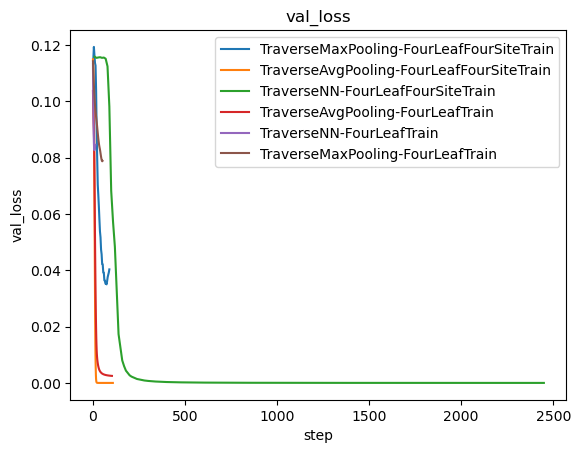

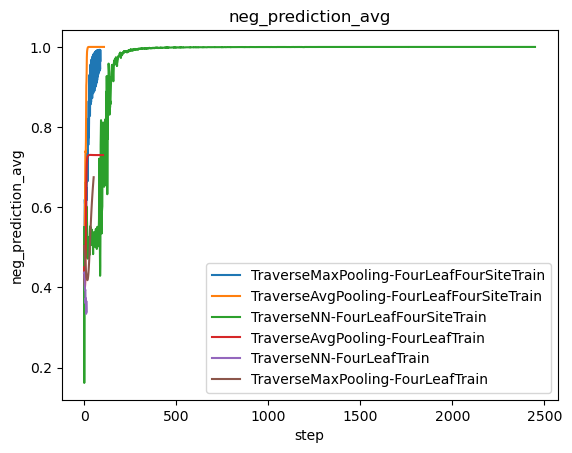

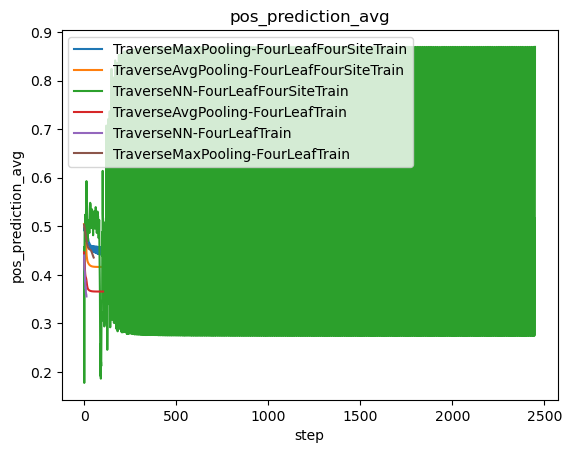

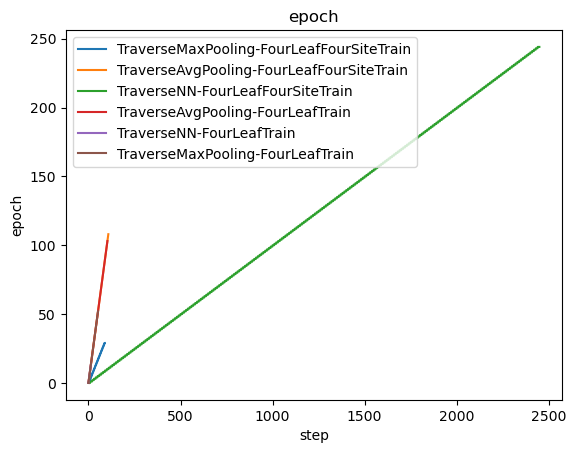

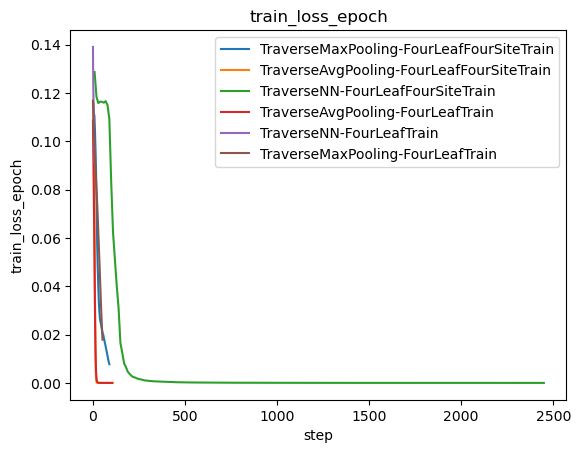

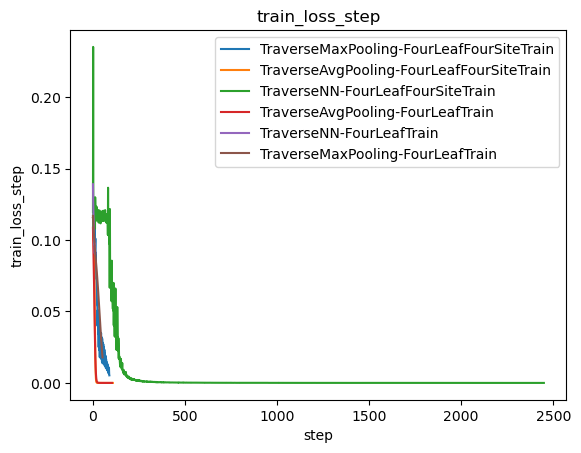

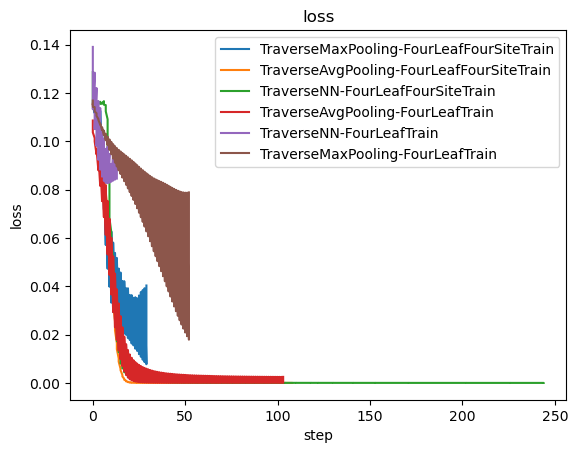

In [121]:
ignore_tags = [
  'train_wall_time',
  'train_final_epoch',
  'validate_final_epoch',
  'validate_wall_time',
  'val_wall_time',
  'train_stopped_early',
  'validate_stopped_early'
]
plot_all_from_summary_dfs(train_dfs, ignore_tags=ignore_tags)

In [88]:
# ignore_tags = [
#   'train_wall_time',
#   'train_final_epoch',
#   'validate_final_epoch',
#   'validate_wall_time',
#   'val_wall_time',
#   'train_stopped_early',
#   'validate_stopped_early'
# ]
# plot_all_from_summary_dfs(test_dfs)

In [ ]:
model = 'TraverseNN'
train_data_name = 'FourLeafTrain'
test_data_name = 'FourLeafTest'

